In [6]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from skimage import util
from skimage.filters import threshold_otsu
from skimage.io import imread
from skimage.measure import label, regionprops_table
from skimage.morphology import closing, disk, opening, remove_small_holes
from skimage.segmentation import expand_labels


In [7]:
image_folder = Path(r"Z:\\Bel\\Marina_Area_PDO\\260310")
images = sorted(image_folder.glob("*.png"))
segmented_stack = imread(image_folder / "marina_segmented_stack.tif")

if len(images) != segmented_stack.shape[0]:
    raise ValueError(
        f"Found {len(images)} PNG images but {segmented_stack.shape[0]} segmentation slices."
    )

image FL12_ARI_day6_4x_dev1_0037_TRANS.png: method=Segmentation, solidity=0.961, major_axis=1214.9 px, minor_axis=1143.0 px, area=1086165 px


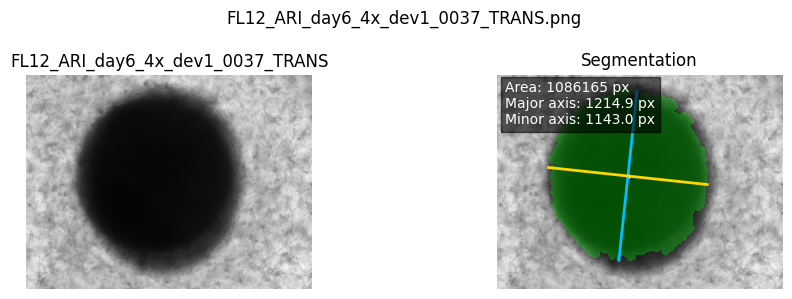

image FL12_ARI_day6_4x_dev2_0036_TRANS.png: method=Segmentation, solidity=0.960, major_axis=1192.3 px, minor_axis=849.9 px, area=783012 px


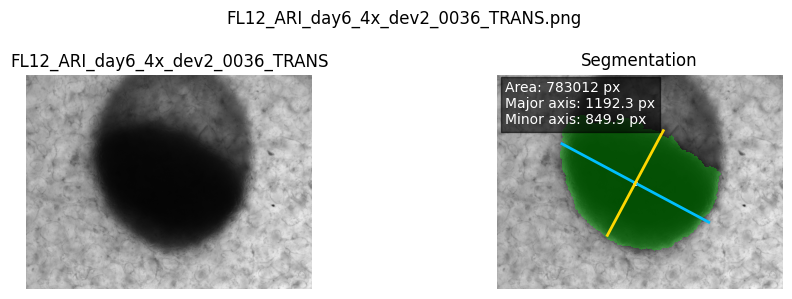

image FL12_ARI_day6_4x_dev3_0035_TRANS.png: method=Segmentation (Extra Opening), solidity=0.895, major_axis=1148.2 px, minor_axis=696.0 px, area=565941 px


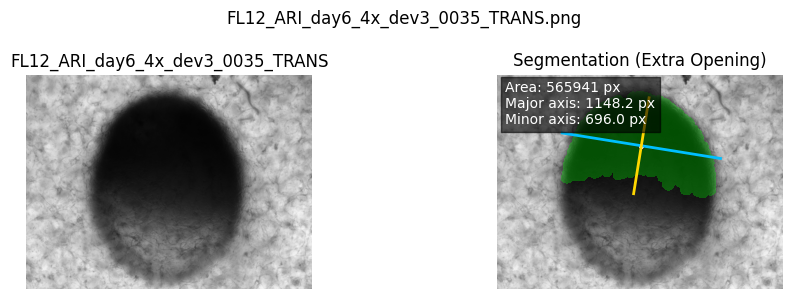

  Applied extra opening for FL12_ARI_day6_4x_dev3_0035_TRANS.png to improve shape solidity.
image FL12_ARI_day6_4x_dev4_0034_TRANS.png: method=Segmentation, solidity=0.956, major_axis=1250.8 px, minor_axis=1120.7 px, area=1093949 px


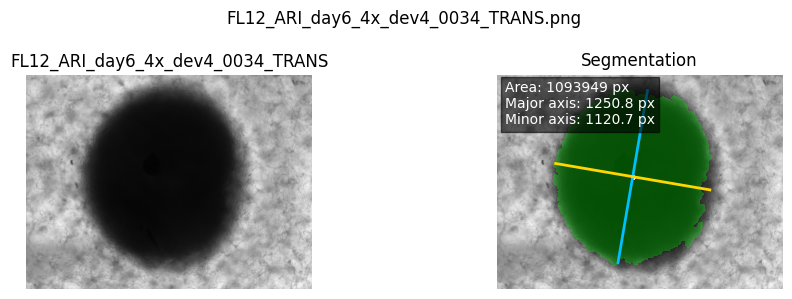

image FL12_ARI_day6_4x_dev5_0033_TRANS.png: method=Segmentation, solidity=0.962, major_axis=1152.8 px, minor_axis=1112.6 px, area=1002004 px


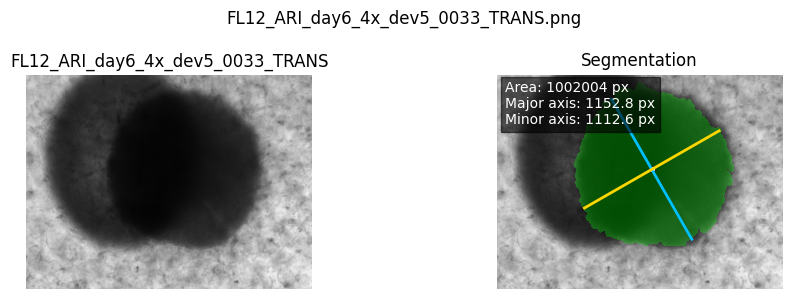

image FL12_ARI_day6_4x_dev6_0032_TRANS.png: method=Segmentation (Extra Opening), solidity=0.932, major_axis=1148.9 px, minor_axis=1035.6 px, area=919755 px


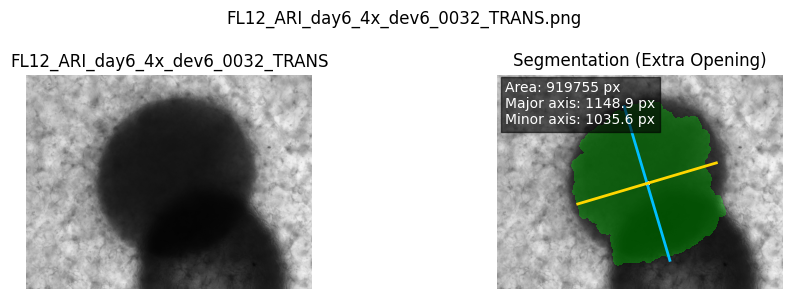

  Applied extra opening for FL12_ARI_day6_4x_dev6_0032_TRANS.png to improve shape solidity.
image FL12_ARI_day6_4x_dev7_0031_TRANS.png: method=Segmentation, solidity=0.953, major_axis=1179.6 px, minor_axis=1133.8 px, area=1043727 px


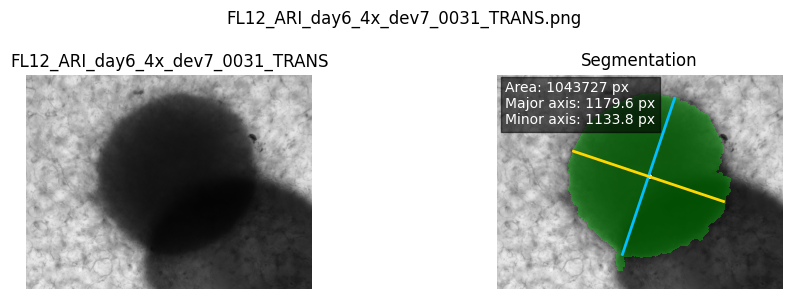

image FL12_ULA_day6_4x_dev1_0038_TRANS.png: method=Segmentation, solidity=0.925, major_axis=1305.2 px, minor_axis=1072.8 px, area=1073440 px


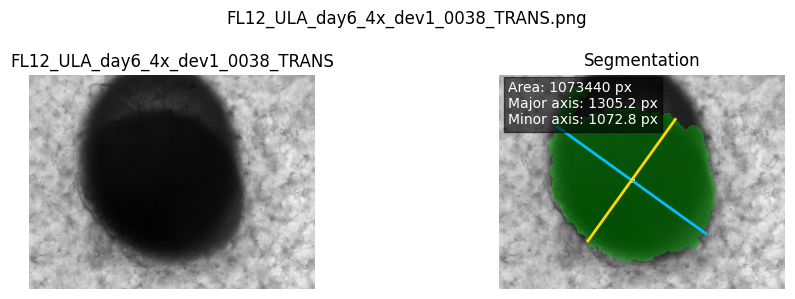

image FL12_ULA_day6_4x_dev2_0039_TRANS.png: method=Segmentation (Extra Opening), solidity=0.942, major_axis=1198.2 px, minor_axis=884.8 px, area=801607 px


In [ ]:
import csv

from skimage.morphology import disk, opening, remove_small_holes

def segment_from_stack_slice(segmented_slice, opening_radius, expand_distance):
    eroded_labels = label(
        remove_small_holes(opening(segmented_slice == 1, disk(opening_radius)), max_size=5000)
    )

    organoid = np.zeros_like(eroded_labels, dtype=bool)
    measurements = {
        "solidity": np.nan,
        "major_axis_length": np.nan,
        "minor_axis_length": np.nan,
        "orientation": np.nan,
        "centroid_row": np.nan,
        "centroid_col": np.nan,
    }

    if eroded_labels.max() > 0:
        label_sizes = np.bincount(eroded_labels.ravel())
        label_sizes[0] = 0
        organoid = eroded_labels == label_sizes.argmax()
        organoid = remove_small_holes(
            expand_labels(organoid.astype(int), distance=expand_distance) > 0,
            max_size=50000,
        )
        organoid = opening(organoid, disk(5))

        measurement_table = regionprops_table(
            label(organoid),
            properties=(
                "label",
                "solidity",
                "major_axis_length",
                "minor_axis_length",
                "orientation",
                "centroid",
            ),
        )
        if len(measurement_table["label"]) > 0:
            measurements = {
                "solidity": measurement_table["solidity"][0],
                "major_axis_length": measurement_table["major_axis_length"][0],
                "minor_axis_length": measurement_table["minor_axis_length"][0],
                "orientation": measurement_table["orientation"][0],
                "centroid_row": measurement_table["centroid-0"][0],
                "centroid_col": measurement_table["centroid-1"][0],
            }

    return organoid, measurements


def format_axis_length(value):
    if np.isnan(value):
        return "n/a"
    return f"{value:.1f} px"


def draw_axis_lines(axis, measurements):
    if np.isnan(measurements["orientation"]):
        return

    centroid_col = measurements["centroid_col"]
    centroid_row = measurements["centroid_row"]
    major_half_length = measurements["major_axis_length"] / 2
    minor_half_length = measurements["minor_axis_length"] / 2
    orientation = measurements["orientation"]

    major_dx = np.sin(orientation) * major_half_length
    major_dy = np.cos(orientation) * major_half_length
    minor_dx = np.cos(orientation) * minor_half_length
    minor_dy = -np.sin(orientation) * minor_half_length

    axis.plot(
        [centroid_col - major_dx, centroid_col + major_dx],
        [centroid_row - major_dy, centroid_row + major_dy],
        color="deepskyblue",
        linewidth=2,
    )
    axis.plot(
        [centroid_col - minor_dx, centroid_col + minor_dx],
        [centroid_row - minor_dy, centroid_row + minor_dy],
        color="gold",
        linewidth=2,
    )
    axis.scatter(centroid_col, centroid_row, color="white", s=18, edgecolors="black", linewidths=0.5)


min_solidity_for_pruning = 0.92
default_expand_distance = 15
extra_opening_expand_distance = 25
figure_output_folder = image_folder / "segmentation_plots"
figure_output_folder.mkdir(exist_ok=True)
area_rows = []

for i, image_path in enumerate(images):
    image = imread(image_path)
    image_title = image_path.name
    image_label = image_path.stem
    used_extra_opening = False

    organoid, measurements = segment_from_stack_slice(
        segmented_stack[i, :, :],
        opening_radius=0,
        expand_distance=default_expand_distance,
    )
    solidity = measurements["solidity"]
    major_axis_length = measurements["major_axis_length"]
    minor_axis_length = measurements["minor_axis_length"]
    method_name = "Segmentation"

    if organoid.any() and not np.isnan(solidity) and solidity < min_solidity_for_pruning:
        organoid, measurements = segment_from_stack_slice(
            segmented_stack[i, :, :],
            opening_radius=10,
            expand_distance=extra_opening_expand_distance,
        )
        solidity = measurements["solidity"]
        major_axis_length = measurements["major_axis_length"]
        minor_axis_length = measurements["minor_axis_length"]
        method_name = "Segmentation (Extra Opening)"
        used_extra_opening = True
    elif not organoid.any():
        method_name = "Segmentation"

    organoid_area = int(organoid.sum())
    area_rows.append({
        "image_name": image_title,
        "organoid_area_px": organoid_area,
        "major_axis_length_px": major_axis_length,
        "minor_axis_length_px": minor_axis_length,
    })

    print(
        f"image {image_title}: method={method_name}, solidity={solidity:.3f}, "
        f"major_axis={format_axis_length(major_axis_length)}, "
        f"minor_axis={format_axis_length(minor_axis_length)}, area={organoid_area} px"
    )

    fig, ax = plt.subplots(ncols=2, figsize=(10, 3))
    fig.suptitle(image_title)

    ax[0].imshow(image, cmap="gray")
    ax[0].set_title(image_label)

    ax[1].imshow(image, cmap="gray")
    ax[1].imshow(
        organoid.astype(int),
        cmap=ListedColormap(["black", "lime"]),
        alpha=np.where(organoid, 0.3, 0.0),
        interpolation="none",
    )
    draw_axis_lines(ax[1], measurements)
    overlay_lines = [
        f"Area: {organoid_area} px",
        f"Major axis: {format_axis_length(major_axis_length)}",
        f"Minor axis: {format_axis_length(minor_axis_length)}",
    ]
    ax[1].text(
        0.03,
        0.97,
        "\n".join(overlay_lines),
        transform=ax[1].transAxes,
        ha="left",
        va="top",
        color="white",
        bbox={"facecolor": "black", "alpha": 0.6, "pad": 3},
    )
    ax[1].set_title(method_name)

    for a in ax:
        a.axis("off")

    plt.tight_layout()
    figure_path = figure_output_folder / f"{image_label}_segmentation_axes.png"
    fig.savefig(figure_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    if used_extra_opening:
        print(f"  Applied extra opening for {image_title} to improve shape solidity.")

csv_path = image_folder / "organoid_areas.csv"
with csv_path.open("w", newline="", encoding="utf-8") as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=[
            "image_name",
            "organoid_area_px",
            "major_axis_length_px",
            "minor_axis_length_px",
        ],
    )
    writer.writeheader()
    writer.writerows(area_rows)

print(f"Saved organoid area summary to {csv_path}")
print(f"Displayed segmentation plots; figure save path is {figure_output_folder}")